In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split

### Linear

In [3]:
df = pd.read_csv("Score.csv")

# Display first few rows
print("Dataset preview:")
print(df.head())

Dataset preview:
   Delay_from_due_date  Num_of_Delayed_Payment  Num_Credit_Inquiries  \
0                    3                       7                     4   
1                    3                       7                     4   
2                    3                       7                     4   
3                    5                       4                     4   
4                    6                       4                     4   

   Credit_Utilization_Ratio  Credit_History_Age Payment_of_Min_Amount  \
0                 26.822620                 265                    No   
1                 31.944960                 265                    No   
2                 28.609352                 267                    No   
3                 31.377862                 268                    No   
4                 24.797347                 269                    No   

   Amount_invested_monthly  Monthly_Balance Credit_Score Credit_Mix  ... Age  \
0                80.415295     

In [4]:
# Keep only numeric columns
df_numeric = df.select_dtypes(include=[np.number])

# Check and handle missing values
df_numeric = df_numeric.fillna(df_numeric.mean())

# Split data into features (X) and target (y)
y = df_numeric["Total_EMI_per_month"]
X = df_numeric.drop(columns=["Total_EMI_per_month"])

# Scale numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Add bias term for manual gradient descent
X_b = np.c_[np.ones((X_scaled.shape[0], 1)), X_scaled]

Iteration 0: Cost = 27036.1293
Iteration 100: Cost = 9452.1652
Iteration 200: Cost = 8764.7366
Iteration 300: Cost = 8574.8843
Iteration 400: Cost = 8467.9849
Iteration 500: Cost = 8393.8271
Iteration 600: Cost = 8338.6273
Iteration 700: Cost = 8296.3536
Iteration 800: Cost = 8263.4174
Iteration 900: Cost = 8237.3565

Final theta (manual GD):
[ 1.05565802e+02  6.26249368e-01  2.23262653e-01  8.27430163e-03
 -1.72175744e+00  1.20313764e+00 -2.94974595e+01 -5.02132295e+01
 -4.97048099e-01  8.06071023e+01 -2.54200694e-01 -2.89535420e-01
 -1.29941210e+00  5.42735604e+01  4.04135746e+01  7.03318281e-01
 -7.12482004e+00]


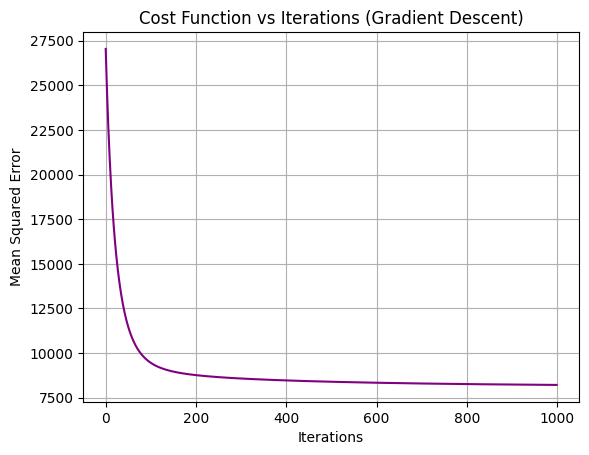

In [5]:
# Manual Gradient Descent Implementation
np.random.seed(42)
theta = np.random.randn(X_b.shape[1], 1)  # Initialize weights
learning_rate = 0.01
iterations = 1000
m = len(y)
y_reshaped = y.values.reshape(-1, 1)

cost_history = []

for i in range(iterations):
    predictions = X_b.dot(theta)
    error = predictions - y_reshaped
    gradients = (2 / m) * X_b.T.dot(error)
    theta = theta - learning_rate * gradients
    cost = np.mean(error**2)
    cost_history.append(cost)
    if i % 100 == 0:
        print(f"Iteration {i}: Cost = {cost:.4f}")

print("\nFinal theta (manual GD):")
print(theta.ravel())

# Plot cost vs iterations
plt.plot(range(iterations), cost_history, color="purple")
plt.title("Cost Function vs Iterations (Gradient Descent)")
plt.xlabel("Iterations")
plt.ylabel("Mean Squared Error")
plt.grid(True)
plt.show()

In [6]:
# Sklearn Linear Regression
lin_reg = LinearRegression()
lin_reg.fit(X_scaled, y)

print("\n=== Comparison ===")
print(
    "Manual Gradient Descent Coefficients:", theta[1:].ravel()[:5], "..."
)  # show first 5
print("Sklearn Coefficients:", lin_reg.coef_[:5], "...")
print("Sklearn Intercept:", lin_reg.intercept_)

# Predictions
y_pred_manual = X_b.dot(theta)
y_pred_sklearn = lin_reg.predict(X_scaled)

# Evaluate both models
print("\n--- Manual Gradient Descent Metrics ---")
print("R² Score:", r2_score(y, y_pred_manual))
print("MAE:", mean_absolute_error(y, y_pred_manual))
print("MSE:", mean_squared_error(y, y_pred_manual))

print("\n--- Sklearn Linear Regression Metrics ---")
print("R² Score:", r2_score(y, y_pred_sklearn))
print("MAE:", mean_absolute_error(y, y_pred_sklearn))
print("MSE:", mean_squared_error(y, y_pred_sklearn))


=== Comparison ===
Manual Gradient Descent Coefficients: [ 0.62624937  0.22326265  0.0082743  -1.72175744  1.20313764] ...
Sklearn Coefficients: [ 0.62260305  0.58913576  0.20597968 -1.6439816   0.74112273] ...
Sklearn Intercept: 105.56580228094272

--- Manual Gradient Descent Metrics ---
R² Score: 0.48098569086293685
MAE: 41.41151782030913
MSE: 8216.391694705972

--- Sklearn Linear Regression Metrics ---
R² Score: 0.5394157619127187
MAE: 47.500936704967025
MSE: 7291.399180929779


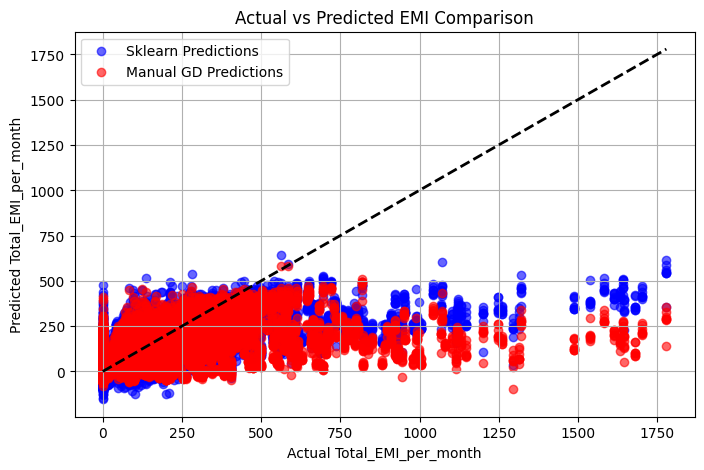

In [7]:
# Optional: Visualize prediction comparison
plt.figure(figsize=(8, 5))
plt.scatter(y, y_pred_sklearn, color="blue", label="Sklearn Predictions", alpha=0.6)
plt.scatter(y, y_pred_manual, color="red", label="Manual GD Predictions", alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], "k--", lw=2)
plt.xlabel("Actual Total_EMI_per_month")
plt.ylabel("Predicted Total_EMI_per_month")
plt.title("Actual vs Predicted EMI Comparison")
plt.legend()
plt.grid(True)
plt.show()

### Logistic

In [8]:
# Load and clean dataset
df = pd.read_csv("brca.csv")

# Fix messy column names (remove quotes/spaces)
df.columns = df.columns.str.strip().str.replace('"', "")

print("Columns loaded:\n", df.columns.tolist())

# Automatically identify target (last column)
y = df.iloc[:, -1]  # categorical target column
X = df.iloc[:, 1:-1]  # all columns except first (index) and last (target)

print("\nTarget column name:", df.columns[-1])
print("Feature count before filtering:", X.shape[1])

Columns loaded:
 ['Unnamed: 0', 'x.radius_mean', 'x.texture_mean', 'x.perimeter_mean', 'x.area_mean', 'x.smoothness_mean', 'x.compactness_mean', 'x.concavity_mean', 'x.concave_pts_mean', 'x.symmetry_mean', 'x.fractal_dim_mean', 'x.radius_se', 'x.texture_se', 'x.perimeter_se', 'x.area_se', 'x.smoothness_se', 'x.compactness_se', 'x.concavity_se', 'x.concave_pts_se', 'x.symmetry_se', 'x.fractal_dim_se', 'x.radius_worst', 'x.texture_worst', 'x.perimeter_worst', 'x.area_worst', 'x.smoothness_worst', 'x.compactness_worst', 'x.concavity_worst', 'x.concave_pts_worst', 'x.symmetry_worst', 'x.fractal_dim_worst', 'y']

Target column name: y
Feature count before filtering: 30


In [9]:
# Drop only non-numeric features from X (keep y as-is)
X = X.select_dtypes(include=[np.number])

# Handle missing values in X
X = X.fillna(X.mean())

# Scale numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [10]:
# Train Logistic Regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluate model
print("\n=== Logistic Regression Results ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


=== Logistic Regression Results ===
Accuracy: 0.9649122807017544

Confusion Matrix:
 [[69  2]
 [ 2 41]]

Classification Report:
               precision    recall  f1-score   support

           B       0.97      0.97      0.97        71
           M       0.95      0.95      0.95        43

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



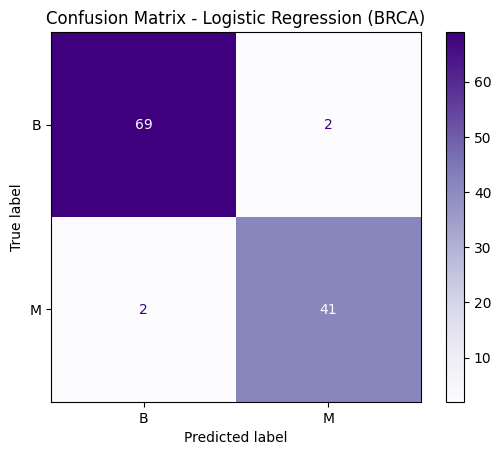

In [11]:
# Visualize confusion matrix
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap="Purples")
plt.title("Confusion Matrix - Logistic Regression (BRCA)")
plt.show()